## Swiggy Sales Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Reading all CSV files

In [2]:
orders = pd.read_csv(r"C:\Users\DELL\Desktop\Data Analytics Project\Swiggy Analysis\data\fact_orders.csv")

dates = pd.read_csv(r"C:\Users\DELL\Desktop\Data Analytics Project\Swiggy Analysis\data\dim_date.csv")

locations = pd.read_csv(r"C:\Users\DELL\Desktop\Data Analytics Project\Swiggy Analysis\data\dim_location.csv")

restaurants = pd.read_csv(r"C:\Users\DELL\Desktop\Data Analytics Project\Swiggy Analysis\data\dim_restaurant.csv")

dishes = pd.read_csv(r"C:\Users\DELL\Desktop\Data Analytics Project\Swiggy Analysis\data\dim_dish.csv")

In [3]:
df = orders.merge(dates,on="date_id",how="left")
df = df.merge(locations,on="location_id",how="left")
df = df.merge(restaurants,on="restaurant_id",how="left")
df = df.merge(dishes,left_on="food_id",right_on="dish_id",how="left")

In [4]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    dayfirst=True,
    errors="coerce"
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_6688\4228442050.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["order_date"] = pd.to_datetime(


In [5]:
df.head()

,order_id,date_id,location_id,restaurant_id,food_id,price,rating,rating_count,order_date,state,city,location,restaurant_name,dish_id,category,dish_name
0,1,1,1,1,1,133.9,4.0,0,2025-06-29,Karnataka,Bengaluru,Rajarajeshwari Nagar,Anand Sweets & Savouries,1,Snack,Butter Murukku200gm
1,2,2,2,2,2,52.0,4.5,25,2025-04-03,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,2,Recommended,Badam Milk
2,3,3,2,2,3,117.0,4.7,48,2025-01-15,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,3,Recommended,Chow Chow Bath
3,4,4,2,2,4,65.0,4.6,65,2025-04-17,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,4,Recommended,Kesari Bath
4,5,5,2,2,5,130.0,4.0,0,2025-03-13,Karnataka,Bengaluru,Kengeri,Srinidhi Sagar Deluxe,5,Recommended,Mix Raitha


In [6]:
print("No. of rows:",df.shape[0])

No. of rows: 197430


In [7]:
print("No. of columns:",df.shape[1])

No. of columns: 16


In [8]:
df.info

<bound method DataFrame.info of         order_id  date_id  location_id  restaurant_id  food_id  price  rating  \
0              1        1            1              1        1  133.9     4.0   
1              2        2            2              2        2   52.0     4.5   
2              3        3            2              2        3  117.0     4.7   
3              4        4            2              2        4   65.0     4.6   
4              5        5            2              2        5  130.0     4.0   
...          ...      ...          ...            ...      ...    ...     ...   
197425    197426      190          989            993    82887  112.0     4.4   
197426    197427      156          989            993    82888  140.0     4.4   
197427    197428       57          989            993    82889  126.0     4.4   
197428    197429      231          989            993    82890   85.0     4.4   
197429    197430      242          989            993    82891  100.0     4.4

In [9]:
df.dtypes

order_id                    int64
date_id                     int64
location_id                 int64
restaurant_id               int64
food_id                     int64
price                     float64
rating                    float64
rating_count                int64
order_date         datetime64[ns]
state                      object
city                       object
location                   object
restaurant_name            object
dish_id                     int64
category                   object
dish_name                  object
dtype: object

In [10]:
df.describe()

,order_id,date_id,location_id,restaurant_id,food_id,price,rating,rating_count,order_date,dish_id
count,197430.00000,197430.000000,197430.000000,197430.000000,197430.000000,197430.000000,197430.000000,197430.000000,197430,197430.000000
mean,98715.50000,121.516092,471.434149,258.741686,22114.367502,268.512920,4.341582,28.321805,2025-05-01 19:41:20.996808960,22114.367502
min,1.00000,1.000000,1.000000,1.000000,1.000000,0.950000,1.500000,0.000000,2025-01-01 00:00:00,1.000000
25%,49358.25000,61.000000,206.000000,33.000000,2599.000000,139.000000,4.300000,0.000000,2025-03-01 00:00:00,2599.000000
50%,98715.50000,122.000000,453.000000,100.000000,10341.500000,229.000000,4.400000,2.000000,2025-05-02 00:00:00,10341.500000
75%,148072.75000,182.000000,747.000000,463.000000,37812.750000,329.000000,4.500000,15.000000,2025-07-01 00:00:00,37812.750000
max,197430.00000,243.000000,995.000000,993.000000,82891.000000,8000.000000,5.000000,999.000000,2025-08-31 00:00:00,82891.000000
std,56993.27616,70.154857,302.904020,292.472935,24259.122654,219.338363,0.422585,87.542593,NaN,24259.122654


## KPI's

In [11]:
total_sales = df["price"].sum()
print("Total Sales(INR):",round(total_sales,2))

Total Sales(INR): 53012505.77


In [12]:
average_rating = df["rating"].mean()
print("Avearge Rating:",round(average_rating,2))

Avearge Rating: 4.34


In [13]:
sum_of_ratings = df["rating"].sum()
print("Ratings count:",sum_of_ratings)

Ratings count: 857158.5


In [14]:
avg_order_value = df["price"].mean()
print("Avg Order Value:",round(avg_order_value,2))

Avg Order Value: 268.51


In [15]:
print("Total Orders",len(df))

Total Orders 197430


In [16]:
df["order_date"].isna().sum()

np.int64(0)

## Chart's Design 

In [17]:
df["YearMonth"] = df["order_date"].dt.to_period("M").astype(str)

monthly_revenue = (
    df.groupby("YearMonth")["price"]
      .sum()
      .reset_index()
)

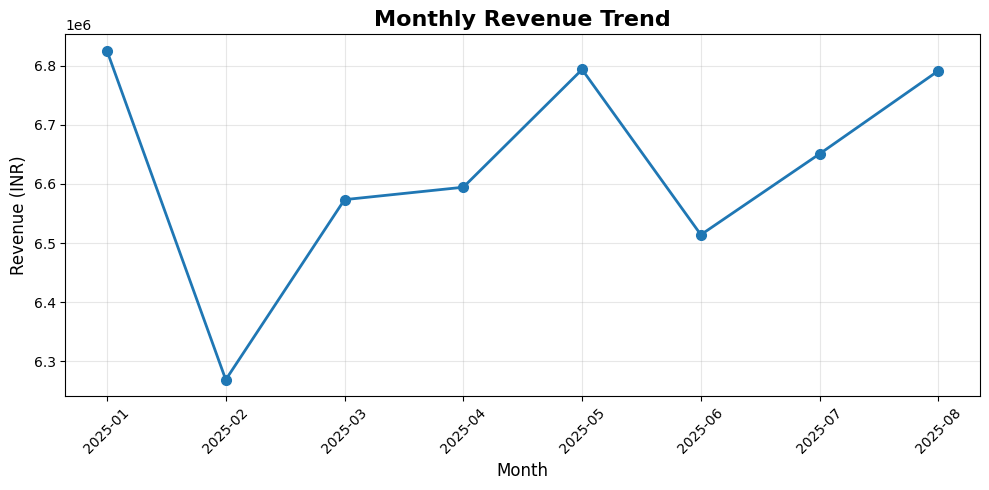

In [18]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["price"],
    marker='o',
    linewidth=2,
    markersize=7
)

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue (INR)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

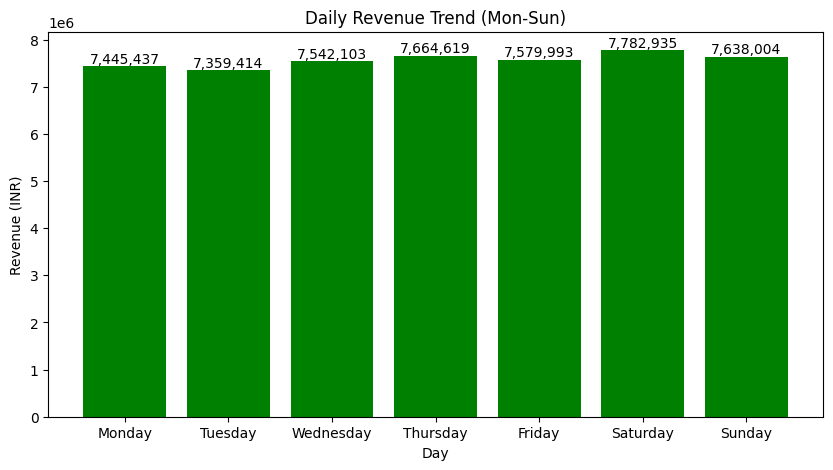

In [19]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["DayName"] = df["order_date"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily_revenue = (
    df.groupby("DayName")["price"]
    .sum()
    .reindex(day_order)
)
plt.figure(figsize=(10,5))
bars = plt.bar(daily_revenue.index,daily_revenue.values,color="green")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.title("Daily Revenue Trend (Mon-Sun)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height,f'{height:,.0f}',ha='center',va='bottom')

plt.tight_layout
plt.show()

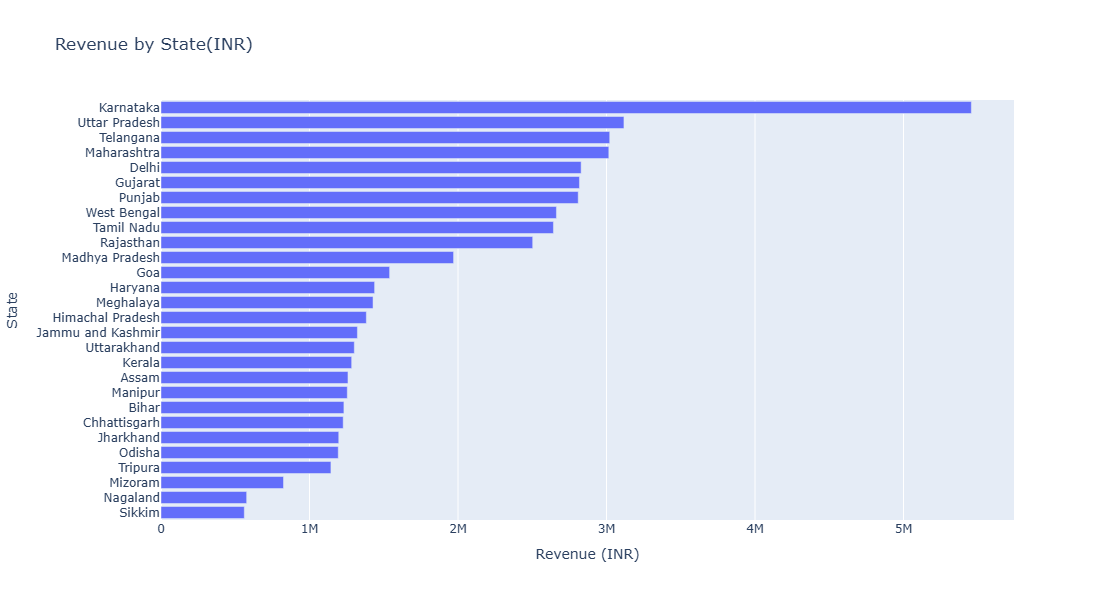

In [20]:
fig = px.bar(
    df.groupby("state",as_index=False)["price"].sum().sort_values("price",ascending=False),
    x="price",
    y="state",
    orientation = "h",
    title="Revenue by State(INR)"
)

fig.update_layout(height=600,yaxis=dict(autorange="reversed"))
fig.update_layout(
    yaxis_title="State",
    xaxis_title="Revenue (INR)"
)
fig.show()

In [21]:
non_veg_keywords = ["chicken","egg","fish","mutton","prawn","biryani","kebab","kabab","non-veg","non veg"]
df["category"] = np.where(
    df["dish_name"].str.lower().str.contains("|".join(non_veg_keywords),na=False),
    "Non-Veg",
    "Veg"
)

In [22]:
food_revenue = (
    df.groupby("category")["price"]
    .sum()
    .reset_index()
)

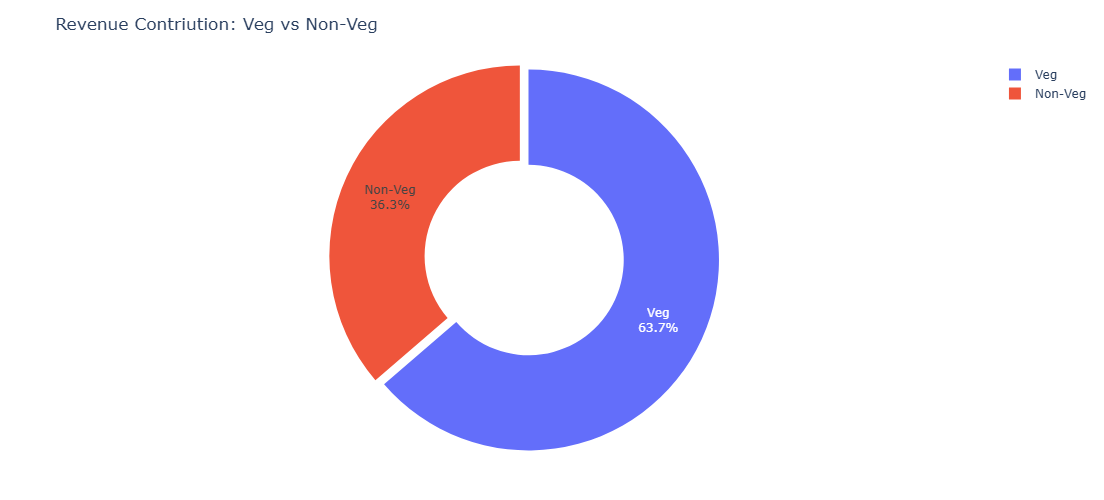

In [23]:
import plotly.express as px
fig = px.pie(
    food_revenue,
    values="price",
    names="category",
    hole=0.5,
    title="Revenue Contriution: Veg vs Non-Veg",
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05,0]
)

fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, r=40)
)
fig.show()

In [25]:
quarterly_summary = (df.assign(
    Order_Date = pd.to_datetime(df["order_date"]),
    Quarter=lambda x: x["order_date"].dt.to_period("Q").astype(str)
    )

    .groupby("Quarter", as_index=False)
    .agg(
        Total_Sales=("price","sum"),
        Avg_Rating=("rating","mean"),
        Total_Orders=("order_date","count")
    )
    .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)
quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


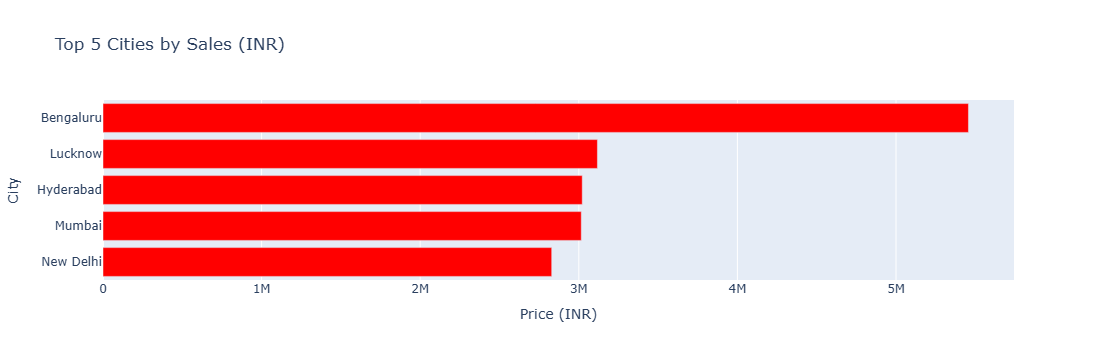

In [26]:
top_5_cities = (
    df.groupby("city")["price"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="price",
    y="city",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)
fig.update_layout(
    xaxis_title="Price (INR)",
    yaxis_title="City"
)
fig.show()

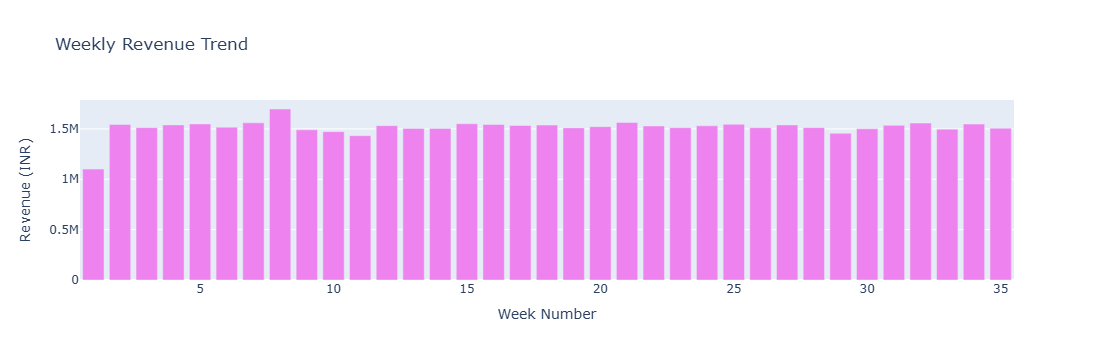

In [27]:
df["Week Number"] = pd.to_datetime(df["order_date"]).dt.isocalendar().week

weekly_revenue= (
    df.groupby("Week Number")["price"]
    .sum()
    .reset_index()
)

fig=px.bar(
    weekly_revenue,
    x="Week Number",
    y="price",
    title="Weekly Revenue Trend",
    color_discrete_sequence=["violet"]
)
fig.update_layout(
    xaxis_title="Week Number",
    yaxis_title="Revenue (INR)"
)
fig.show()

## Creating new excel and csv file

In [32]:
final_df = df[
    [
        "State",
        "City",
        "Order Date",
        "Restaurant Name",
        "Location",
        "Category",
        "Dish Name",
        "Price (INR)",
        "Rating",
        "Rating Count"
    ]
].copy()

final_df["Order Date"] = pd.to_datetime(
    final_df["Order Date"]
).dt.strftime("%d-%m-%Y")

final_df.to_csv(
    r"C:\Users\DELL\Desktop\Data Analytics Project\Swiggy Analysis\Swiggy_Data.csv",
    index=False
)

final_df.to_excel(
    r"C:\Users\DELL\Desktop\Data Analytics Project\Swiggy Analysis\Swiggy_Data.xlsx",
    index=False
)

In [35]:
final_df.to_csv(
    r"C:\Users\DELL\Desktop\Data Analytics Project\Swiggy Analysis\Swiggy_Data.csv",
    index=False,
    date_format="%Y-%m-%d"
)

In [36]:
final_df["Order Date"] = pd.to_datetime(final_df["Order Date"])

C:\Users\DELL\AppData\Local\Temp\ipykernel_6688\3760816971.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  final_df["Order Date"] = pd.to_datetime(final_df["Order Date"])


In [37]:
final_df.to_excel("Swiggy_Data_Cleaned.xlsx", index=False)